# 📊 [Phase 1] 전역 통계 및 결측치 탐색 (Global EDA)

## 1. 분석 개요
- **목적:** 모델링 진입 전, 전체 데이터의 기본 구조를 파악하고 타겟 및 주요 거시적 변수(`hour`, `day_of_week`, `gender`, `age_group`)의 패턴과 클릭률(CTR) 추이를 탐색함.
- **분석 대상:** `train.parquet` 전체 데이터 (총 10,704,179건)
- **사용 도구:** DuckDB (메모리 절약형 고속 데이터 집계), Matplotlib / Seaborn (시각화)

---

## 2. 주요 분석 결과

### 📌 ① 타겟 변수 불균형 (`clicked`) 분석
- **데이터 구성:**
  - 비클릭 (0): 10,500,000건 (**98.09%**)
  - 클릭 (1): 204,179건 (**1.91%**)
- **💡 핵심 인사이트 & 전략:**
  - 정답 레이블이 0에 극단적으로 치우친 심각한 **불균형(Imbalanced) 데이터셋**임.
  - 일반적인 정확도(Accuracy) 지표는 평가를 왜곡하므로, 대회의 평가 표준인 AUC 또는 LogLoss 최적화에 집중해야 함.
  - 교차 검증 시 각 Fold의 정답 비율을 유지하는 `Stratified K-Fold` 분할 방식이 필수적임.

### 📌 ② 시간대별 평균 클릭률 (CTR by `hour`) 추이
- **패턴 분석:**
  - **최고점:** 새벽 2시 ~ 3시 사이 클릭률이 최고점(약 2.5% 부근) 형성.
  - **최저점:** 오전 7시 ~ 10시 사이(출근/업무 시간) 클릭률이 최저점(약 1.7%대) 형성.
  - 오후 1시(점심)와 오후 5~6시(퇴근)에 소폭 반등하는 패턴을 보임.
- **💡 피처 엔지니어링 아이디어:**
  - 시간(`hour`)을 변별력이 튀는 구간으로 묶어 파생 변수 생성 고려 (예: `Is_Night`, `Is_Working_Hour`).

### 📌 ③ 요일별 평균 클릭률 (CTR by `day_of_week`) 추이
- **패턴 분석:**
  - 2번 요일의 평균 클릭률이 약 2.1%로 가장 높음.
  - 1번, 7번 요일은 1.6%~1.7% 수준으로 가장 낮게 형성됨.
- **💡 피처 엔지니어링 아이디어:**
  - 트리 모델 학습 시 `day_of_week`를 단순 수치형이 아닌 **범주형 변수(Categorical)**로 명확히 지정하여 요일 간의 비선형적 편차를 올바르게 학습하도록 유도해야 함.

### 📌 ④ 인구통계학적 특성 (`gender` & `age_group`) 분석
- **패턴 분석:**
  - **성별(`gender`):** 1번 성별이 2번 성별보다 클릭률이 미세하게 높으나 유의미한 큰 차이는 아님.
  - **연령대(`age_group`):** 1번 연령대의 클릭률이 **약 6.7%로 압도적인 1위**를 기록함. (타 연령대는 평균 1.5~2.2% 수준). 8번 연령대도 평균 대비 소폭 높음.
- **💡 피처 엔지니어링 아이디어:**
  - 특정 연령대(`age_group == 1`) 여부가 광고 클릭을 예측하는 매우 강력한 분류 기준(Key Feature)으로 작용할 것임.

---

## 3. 결론 및 Next Step

> **총평:** 1,070만 건의 거대한 스케일 속에서 타겟 레이블은 1.91%로 매우 희소하지만, 시간/요일/특정 연령대(1번)에 따른 클릭 변동 모멘텀이 확실히 존재함을 검증 완료함.

- **🚨 이슈 사항 리포트:** 실행 중 `app.log` 상에서 메모리 부족으로 인한 커널 재시작(Kernel Restart) 현상이 관찰됨. 대용량 파생 변수 생성 시 엄격한 메모리 최적화 관리가 필수적임.
- **➡️ 다음 단계:** 테이블 형태의 거시적 정형 피처 탐색이 완료되었으므로, 본 대회의 핵심 변별력이 될 유저 과거 행동 이력 데이터(`seq` 컬럼)를 파싱하고 가공하는 **`02_Feature_Engineering_and_Modeling.ipynb` (시퀀스 엔지니어링 및 모델링)** 단계로 진입함.

# 기본 세팅

In [ ]:
import duckdb
import pandas as pd
import os
from google.colab import drive

In [ ]:
# 1. 환경 세팅
drive.mount('/content/drive')
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/CTR_Dacon'
TRAIN_PATH = os.path.join(BASE_DIR, '원본데이터/train.parquet')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. 통계량 추출 (DuckDB 기반)

In [ ]:
# 2. DuckDB 인메모리 DB 연결 및 총 데이터 수 계산
conn = duckdb.connect()
total_rows = conn.execute(f"SELECT count(*) FROM '{TRAIN_PATH}'").fetchone()[0]
print(f"✅ 총 데이터: {total_rows:,}건")

✅ 총 데이터: 10,704,179건


In [ ]:
# 3. 스키마에서 컬럼 목록 가져오기
columns_info = conn.execute(f"DESCRIBE SELECT * FROM '{TRAIN_PATH}'").fetchall()

stats_list = []
print("🚀 DuckDB 기반 Out-of-Core 통계 추출 시작 (메모리 로드 없음)...")

🚀 DuckDB 기반 Out-of-Core 통계 추출 시작 (메모리 로드 없음)...


In [ ]:
# 4. 각 컬럼별로 디스크에서 직접 통계 계산
for idx, col_info in enumerate(columns_info):
    col_name = col_info[0]
    dtype = col_info[1]

    # 4-1. 결측치(Null) 계산
    null_query = f"SELECT count(*) FROM '{TRAIN_PATH}' WHERE {col_name} IS NULL"
    null_count = conn.execute(null_query).fetchone()[0]
    null_ratio = (null_count / total_rows) * 100

    # 4-2. 고유값(Unique) 근사치 계산 (메모리 및 속도 최적화를 위해 approx 함수 사용)
    # Target(clicked)이나 범주형 피처의 상태를 대략적으로 파악하기에 충분함
    unique_query = f"SELECT approx_count_distinct({col_name}) FROM '{TRAIN_PATH}'"
    n_unique = conn.execute(unique_query).fetchone()[0]

    stats_list.append({
        'Feature': col_name,
        'Dtype': dtype,
        'Null_Count': null_count,
        'Null_Ratio(%)': round(null_ratio, 2),
        'Unique_Count': n_unique
    })

    # 진행 상황 출력 (20개 컬럼 단위)
    if (idx + 1) % 20 == 0:
        print(f"[{idx + 1}/{len(columns_info)}] {col_name} 통계 추출 완료")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[20/119] l_feat_14 통계 추출 완료
[40/119] feat_e_7 통계 추출 완료
[60/119] feat_b_3 통계 추출 완료
[80/119] feat_a_17 통계 추출 완료
[100/119] history_b_12 통계 추출 완료


In [ ]:
# 5. 최종 결과 DataFrame 변환 및 결측치 내림차순 정렬
stats_df = pd.DataFrame(stats_list)

print("\n=== 전역 통계 분석 결과 (결측치 비율 내림차순) ===")
display(stats_df.sort_values(by='Null_Ratio(%)', ascending=False).head(30))


=== 전역 통계 분석 결과 (결측치 비율 내림차순) ===


,Feature,Dtype,Null_Count,Null_Ratio(%),Unique_Count
35,feat_e_3,FLOAT,1085557,10.14,97
65,feat_a_3,FLOAT,18598,0.17,6
66,feat_a_4,FLOAT,18598,0.17,6
67,feat_a_5,FLOAT,18598,0.17,546
68,feat_a_6,FLOAT,18598,0.17,10
80,feat_a_18,FLOAT,18598,0.17,7
79,feat_a_17,FLOAT,18598,0.17,10
71,feat_a_9,FLOAT,18598,0.17,10
72,feat_a_10,FLOAT,18598,0.17,6
73,feat_a_11,FLOAT,18598,0.17,9


# 2. 타겟 분포 및 시각화

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

In [ ]:
import logging
import warnings

# 1. matplotlib 폰트 매니저의 경고(Warning) 로그 끄기
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 2. 기타 자잘한 파이썬 경고창도 모두 숨기기
warnings.filterwarnings('ignore')

In [ ]:
# 1. 폰트 재설치 및 캐시 삭제 (커널 초기화 대비)
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

#  설치된 나눔 폰트 경로를 자동으로 찾아서 적용 (하드코딩 방지)
sys_font = fm.findSystemFonts()
nanum_font_path = [f for f in sys_font if 'Nanum' in f][0] # 설치된 나눔 폰트 중 첫 번째 픽
font_prop = fm.FontProperties(fname=nanum_font_path)

# Matplotlib 전역 폰트 설정 업데이트
plt.rc('font', family=font_prop.get_name())
plt.rcParams['axes.unicode_minus'] = False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (39.9 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and direct

In [ ]:
print("1. 타겟(clicked) 불균형 비율 확인...")
target_dist = conn.execute(f"SELECT clicked, count(*) as cnt FROM '{TRAIN_PATH}' GROUP BY clicked").df()
target_dist['ratio(%)'] = round((target_dist['cnt'] / total_rows) * 100, 2)
display(target_dist)

print("\n2. 시각화를 위한 10% 무작위 샘플링 데이터 로드 중...")
sample_query = f"""
    SELECT gender, age_group, day_of_week, hour, clicked
    FROM '{TRAIN_PATH}'
    USING SAMPLE 10 PERCENT (bernoulli)
"""
sample_df = conn.execute(sample_query).df()
print(f"✅ 샘플링 완료! 데이터 크기: {len(sample_df):,}건")

1. 타겟(clicked) 불균형 비율 확인...


,clicked,cnt,ratio(%)
0,0,10500000,98.09
1,1,204179,1.91



2. 시각화를 위한 10% 무작위 샘플링 데이터 로드 중...
✅ 샘플링 완료! 데이터 크기: 1,069,945건


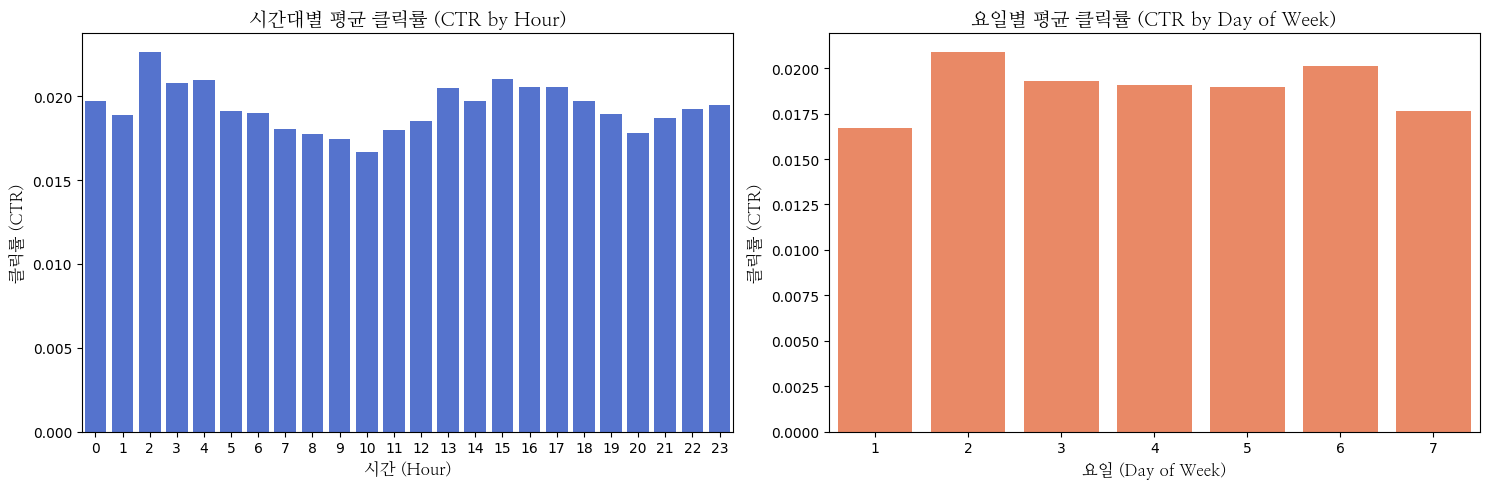

In [ ]:
# 3. 요일별 / 시간대별 클릭률(CTR) 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 시간대별 클릭률 (hour)
sample_df['hour_int'] = sample_df['hour'].astype(int)
sns.barplot(data=sample_df, x='hour_int', y='clicked', ax=axes[0], errorbar=None, color='royalblue')
axes[0].set_title('시간대별 평균 클릭률 (CTR by Hour)', fontproperties=font_prop, fontsize=14)
axes[0].set_xlabel('시간 (Hour)', fontproperties=font_prop, fontsize=12)
axes[0].set_ylabel('클릭률 (CTR)', fontproperties=font_prop, fontsize=12)

# 요일별 클릭률 (day_of_week)
# 데이터 정렬을 위해 integer 형변환 후 플로팅
sample_df['day_int'] = sample_df['day_of_week'].astype(int)
sns.barplot(data=sample_df, x='day_int', y='clicked', ax=axes[1], errorbar=None, color='coral')
axes[1].set_title('요일별 평균 클릭률 (CTR by Day of Week)', fontproperties=font_prop, fontsize=14)
axes[1].set_xlabel('요일 (Day of Week)', fontproperties=font_prop, fontsize=12)
axes[1].set_ylabel('클릭률 (CTR)', fontproperties=font_prop, fontsize=12)

plt.tight_layout()
plt.show()

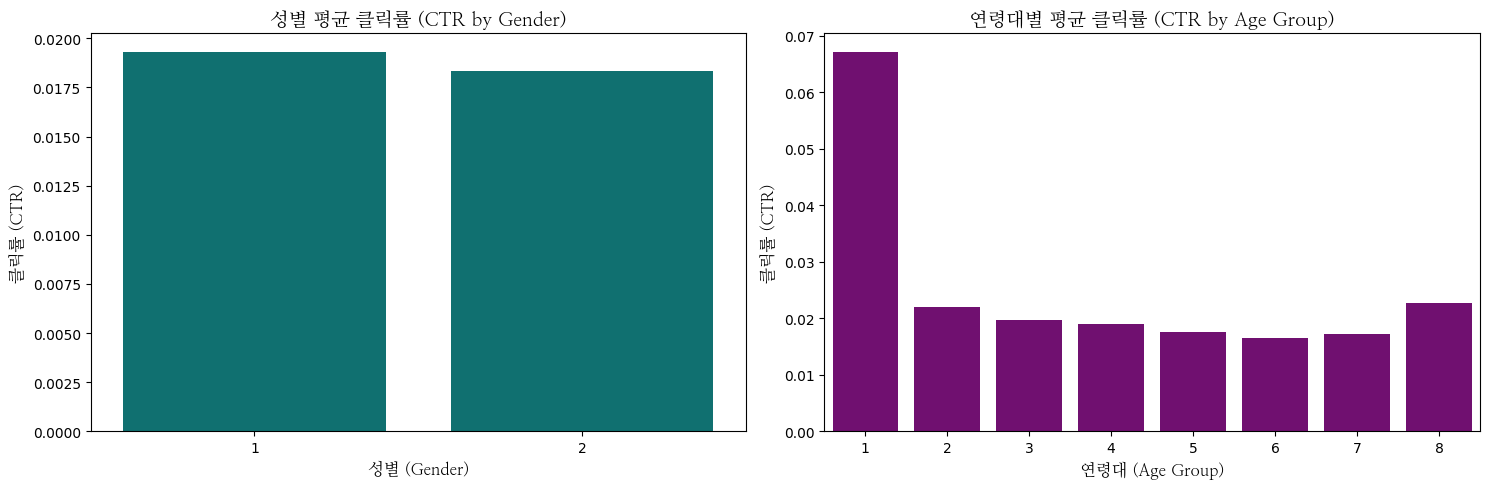

In [ ]:
# 기존에 만들어둔 sample_df와 폰트 설정(font_prop) 재사용
# null 값 제거 및 보기 좋게 정렬하기 위한 형변환
plot_df = sample_df.dropna(subset=['gender', 'age_group']).copy()
plot_df['gender'] = plot_df['gender'].astype(float).astype(int).astype(str)
plot_df['age_group'] = plot_df['age_group'].astype(float).astype(int).astype(str)

# 4. 성별 / 연령대별 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 성별 클릭률
sns.barplot(data=plot_df, x='gender', y='clicked', ax=axes[0], errorbar=None, color='teal')
axes[0].set_title('성별 평균 클릭률 (CTR by Gender)', fontproperties=font_prop, fontsize=14)
axes[0].set_xlabel('성별 (Gender)', fontproperties=font_prop, fontsize=12)
axes[0].set_ylabel('클릭률 (CTR)', fontproperties=font_prop, fontsize=12)

# 연령대별 클릭률 (정렬)
age_order = sorted(plot_df['age_group'].unique(), key=lambda x: int(x))
sns.barplot(data=plot_df, x='age_group', y='clicked', ax=axes[1], errorbar=None, color='purple', order=age_order)
axes[1].set_title('연령대별 평균 클릭률 (CTR by Age Group)', fontproperties=font_prop, fontsize=14)
axes[1].set_xlabel('연령대 (Age Group)', fontproperties=font_prop, fontsize=12)
axes[1].set_ylabel('클릭률 (CTR)', fontproperties=font_prop, fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# 01번 노트북의 모든 분석이 끝났으므로 DB 연결 최종 종료
conn.close()